<a href="https://colab.research.google.com/github/itskevalchaudhari/AIML-Practicals/blob/main/Practical-07/Practical_07_SVM_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 07: Support Vector Machine for Regression

## Aim

To implement Support Vector Machine (SVM) regression for predicting a continuous target variable and evaluate the performance of the model using suitable regression metrics.

## Theory

Support Vector Regression (SVR) is a supervised machine learning algorithm used to predict continuous numerical values. It is the regression counterpart of Support Vector Classification.

SVR attempts to find a regression function that fits the training data while allowing a specified margin of tolerance around the predicted values. The algorithm tries to keep as many data points as possible within this margin while maintaining a simple and generalized model.

The basic regression function can be represented as:

f(x) = wᵀx + b

where:

- `w` = weight vector
- `x` = input feature vector
- `b` = bias/intercept

SVR uses an epsilon-insensitive loss function. Errors within the epsilon (ε) margin are not penalized.

The optimization problem aims to minimize:

1/2 ||w||² + C Σ(ξᵢ + ξᵢ*)

subject to the SVR constraints.

### Important Parameters

- **C:** Controls the trade-off between model complexity and training errors.
- **epsilon (ε):** Defines the margin within which errors are ignored.
- **kernel:** Defines the mathematical transformation used to model relationships between features.

Common kernels include:

- Linear
- Polynomial
- Radial Basis Function (RBF)

In this practical, the **Support Vector Regression (SVR)** model with an **RBF kernel** is used.

### Model Identity

The model used is:

`SVR(kernel='rbf')`

from the `sklearn.svm` module.

### Evaluation Metrics

The model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the Diabetes dataset
diabetes = load_diabetes()

# Create DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (442, 11)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training samples: 353
Testing samples: 89
Number of features: 10


In [3]:
# Standardize the input features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [4]:
# Create and train the Support Vector Regression model

svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1
)

svr_model.fit(X_train_scaled, y_train)

print("Support Vector Regression model trained successfully.")
print("\nModel Parameters:")
print("Kernel:", svr_model.kernel)
print("C:", svr_model.C)
print("Epsilon:", svr_model.epsilon)

Support Vector Regression model trained successfully.

Model Parameters:
Kernel: rbf
C: 100
Epsilon: 0.1


In [5]:
# Make predictions on the test data

y_pred = svr_model.predict(X_test_scaled)

print("First 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(np.round(y_pred[:10], 2))

First 10 Actual Values:
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]

First 10 Predicted Values:
[122.59 183.42 177.94 220.68 109.38 117.33 273.34 201.32 115.86 111.27]


In [6]:
# Calculate regression evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("SUPPORT VECTOR REGRESSION PERFORMANCE")
print("=" * 45)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"R² Score (%): {r2 * 100:.2f}%")

SUPPORT VECTOR REGRESSION PERFORMANCE
Mean Absolute Error (MAE): 39.4187
Mean Squared Error (MSE): 2607.5423
Root Mean Squared Error (RMSE): 51.0641
R² Score: 0.5078
R² Score (%): 50.78%


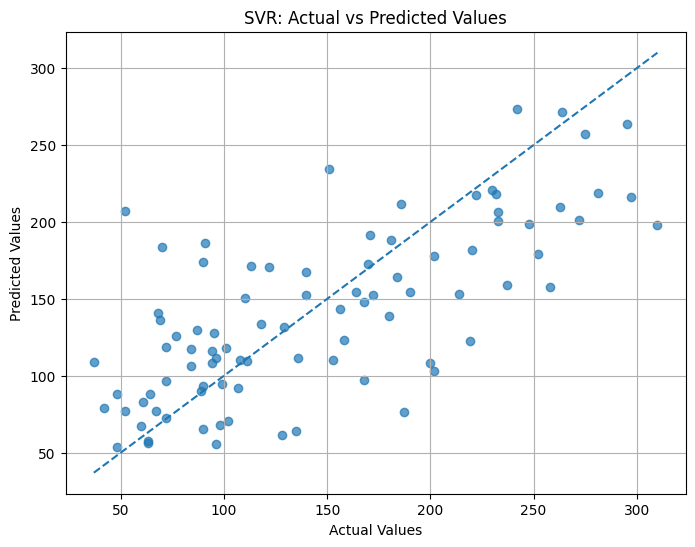

In [7]:
# Plot Actual vs Predicted values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVR: Actual vs Predicted Values")
plt.grid(True)

plt.show()

In [8]:
# Display final SVR performance

print("=" * 45)
print("FINAL SVR MODEL PERFORMANCE")
print("=" * 45)

print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")
print(f"R² (%)   : {r2 * 100:.2f}%")

FINAL SVR MODEL PERFORMANCE
MAE      : 39.4187
MSE      : 2607.5423
RMSE     : 51.0641
R² Score : 0.5078
R² (%)   : 50.78%


Result:

The Support Vector Regression (SVR) model was successfully implemented and evaluated on the dataset. The model achieved an MAE of 39.4187, MSE of 2607.5423, RMSE of 51.0641, and an R² score of 0.5078. The model explains approximately 50.78% of the variation in the target variable.

Conclusion:

Thus, the SVR algorithm was successfully implemented for regression analysis. The obtained R² score indicates that the model provides a moderate level of prediction performance. The actual versus predicted plot was also used to visually analyze the performance of the model.